In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
google_api_key=os.getenv("GOOGLE_API_KEY")

In [3]:
from llama_index.core import Document
from llama_index.core import SimpleDirectoryReader
from llama_index.core.node_parser import SentenceWindowNodeParser
from llama_index.core import load_index_from_storage
from llama_index.core import Settings
from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.core.postprocessor import MetadataReplacementPostProcessor
from llama_index.core.indices.postprocessor import SentenceTransformerRerank
from llama_index.llms.google_genai import GoogleGenAI
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding
from llama_index.embeddings.google_genai.base import types

In [16]:
documents = SimpleDirectoryReader("data").load_data()

In [5]:
documents

[Document(id_='86763032-82b0-491e-b4b6-32a6d483cbdb', embedding=None, metadata={'page_label': '1', 'file_name': 'laws_of_motion.pdf', 'file_path': 'd:\\Projects\\AI Legal Research Agent\\v1.2.0\\notebooks\\data\\laws_of_motion.pdf', 'file_type': 'application/pdf', 'file_size': 1982170, 'creation_date': '2025-09-19', 'last_modified_date': '2025-09-03'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='CHAPTER FOUR\nLAWS OF MOTION\n4.1  INTRODUCTION\nIn the preceding Chapter, our concern was to describe the\nmotion of a particle in space quantitatively. W e saw that\nuniform motion needs the concept of velocity alone whereas\nnon-uniform moti

In [17]:
document = Document(text="\n\n".join([doc.text for doc in documents]))

In [7]:
document.text

'CHAPTER FOUR\nLAWS OF MOTION\n4.1  INTRODUCTION\nIn the preceding Chapter, our concern was to describe the\nmotion of a particle in space quantitatively. W e saw that\nuniform motion needs the concept of velocity alone whereas\nnon-uniform motion requires the concept of acceleration in\naddition.  So far, we have not asked the question as to what\ngoverns the motion of bodies. In this chapter, we turn to this\nbasic question.\nLet us first guess the answer based on our common\nexperience. To move a football at rest, someone must kick it.\nTo throw a stone upwards, one has to  give it an upward\npush.  A breeze causes the branches of a tree to swing; a\nstrong wind can even move heavy objects. A boat moves in a\nflowing river without anyone rowing it. Clearly, some external\nagency is needed to provide force to move a body from rest.\nLikewise, an external force is needed also to retard or stop\nmotion.  You can stop a ball rolling down an inclined plane by\napplying a force against th

In [18]:
def get_sentence_window_index(documents, index_dir, sentence_window_size=3):
    Node_parser = SentenceWindowNodeParser.from_defaults(
        window_size=sentence_window_size,
        window_metadata_key="window",
        original_text_metadata_key="original_sentence",
    )

    Settings.llm = GoogleGenAI(
    model="gemini-2.5-flash",
    api_key=google_api_key,
    generation_config=types.GenerateContentConfig(
        safety_settings=[
            types.SafetySetting(
                category= types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
                threshold=types.HarmBlockThreshold.BLOCK_NONE
            ),
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_CIVIC_INTEGRITY,
                threshold=types.HarmBlockThreshold.BLOCK_NONE
            ),
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_HARASSMENT,
                threshold=types.HarmBlockThreshold.BLOCK_NONE
            ),
            types.SafetySetting(
                category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
                threshold=types.HarmBlockThreshold.BLOCK_NONE
            ),
        ]
    ))
    Settings.embed_model = GoogleGenAIEmbedding(
        model_name="gemini-embedding-001",
        api_key=google_api_key,
        embedding_config=types.EmbedContentConfig(
            output_dimensionality=1536,
            task_type="RETRIEVAL_DOCUMENT"
        )
    )
    Settings.node_parser = Node_parser

    if not os.path.exists(index_dir):
        sentence_index = VectorStoreIndex.from_documents([document])
        sentence_index.storage_context.persist(persist_dir=index_dir)
        
    else:
        sentence_index = load_index_from_storage(StorageContext.from_defaults(persist_dir=index_dir))
    return sentence_index

In [19]:
def get_sentence_window_engine(sentence_index):
    
    postprocessor = MetadataReplacementPostProcessor(target_metadata_key="window",)
    rerank = SentenceTransformerRerank(top_n=2, model="BAAI/bge-reranker-base") 
    sentence_window_engine = sentence_index.as_query_engine(similarity_top_k=6, node_postprocessors=[postprocessor, rerank])
    
    return sentence_window_engine

In [20]:
index_dir = "sentence_index_1"
sw_index_1 = get_sentence_window_index(documents, index_dir, sentence_window_size=3)
sw_engine_1 = get_sentence_window_engine(sw_index_1)

In [21]:
window_response = sw_engine_1.query(
    "How can I calculate the final velocity if I have initial velocity and acceleration after 10 seconds?"
)
window_response.response

'The final velocity can be calculated by adding the product of acceleration and time to the initial velocity. This can be expressed as: final velocity = initial velocity + (acceleration × time).'

In [29]:
from trulens.core.session import TruSession
from trulens.apps.llamaindex import TruLlama
from trulens.providers.google import Google
from trulens.core import Feedback
import numpy as np

tru = TruSession()
tru.reset_database()
# Initialize provider class
provider = Google()

def get_evaluation_response(rag_engine, app_id, eval_questions):
    # Define a groundedness feedback function
    f_groundedness = (
    Feedback(provider.groundedness_measure_with_cot_reasons,name="Groundedness")
    .on_context(collect_list=True)
    .on_output()
    )

    # Question/answer relevance
    f_answer_relevance = (
    Feedback(provider.relevance_with_cot_reasons, name="Answer Relevance")
    .on_input()
    .on_output()
    )

    # Question/context relevance
    f_context_relevance =  (
    Feedback(provider.context_relevance_with_cot_reasons,name="Context Relevance")
    .on_input()
    .on_context(collect_list=True)
    .aggregate(np.mean)
    )

    # Recorder
    tru_query_engine_recorder = TruLlama(
        rag_engine,
        app_id=app_id,
        feedbacks=[f_groundedness, f_answer_relevance, f_context_relevance]
    )

    for question in eval_questions:
        with tru_query_engine_recorder as recording:
            rag_engine.query(question)

    records = recording.get()
    return records


Updating app_name and app_version in apps table: 0it [00:00, ?it/s]
Updating app_id in records table: 0it [00:00, ?it/s]
Updating app_json in apps table: 0it [00:00, ?it/s]


In [30]:
eval_questions=[
    "State Newton’s First Law of Motion. Why is it also called the Law of Inertia?",
    "A body of mass 5 kg is acted upon by two forces of 10 N and 20 N at right angles to each other. Find the resultant acceleration of the body.",
    "Explain Newton’s Third Law of Motion with two real-life examples.",
    "A truck of mass 2000 kg moves with a uniform velocity of 54 km/h. Calculate the force required to stop it in 10 seconds.",
    "A projectile is fired with an initial velocity of 20 m/s at an angle of 30° with the horizontal. Find the time of flight, maximum height, and horizontal range.",
    "A river is 500 m wide and flows at 3 m/s. A boat has a speed of 5 m/s in still water. Find the time taken by the boat to cross the river if it heads perpendicular to the bank, and also find the drift.",
    "Derive the formula for centripetal acceleration and explain why a car skids on a curved road if the speed is too high.",
    "State and prove the work-energy theorem.",
    "A spring of spring constant 200 N/m is compressed by 0.1 m. Find the potential energy stored in the spring.",
    "A body of mass 2 kg is lifted vertically to a height of 10 m. Find the work done against gravity and the potential energy gained."
]

In [31]:
records = get_evaluation_response(
    sw_engine_1,
    app_id='sentence window engine',
    eval_questions = eval_questions
)


instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'>
instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class 'llama_index.core.base.embeddings.base.BaseEmbedding'>
instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class 'llama_index.core.schema.TransformComponent'>
instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class 'llama_index.core.schema.BaseComponent'>
instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class 'pydantic.main.BaseModel'>
instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class 'llama_index_instrumentation.DispatcherSpanMixin'>
instrumenting <class 'llama_index.embeddings.google_genai.base.GoogleGenAIEmbedding'> for base <class '

d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(
d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(
d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(


d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(
d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(
d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(
d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(
d:\Projects\AI Legal Research Agent\.venv\Lib\site-packages\trulens\feedback\llm_provider.py:2134: UserWarning: Failed to process and remove trivial statements.

In [33]:
display(records)
tru.run_dashboard()

Starting dashboard ...


Accordion(children=(VBox(children=(VBox(children=(Label(value='STDOUT'), Output())), VBox(children=(Label(valu…

Dashboard started at http://localhost:59681 .


<Popen: returncode: None args: ['streamlit', 'run', '--server.headless=True'...>

![Screenshot 2025-09-20 032956.png](<attachment:Screenshot 2025-09-20 032956.png>)
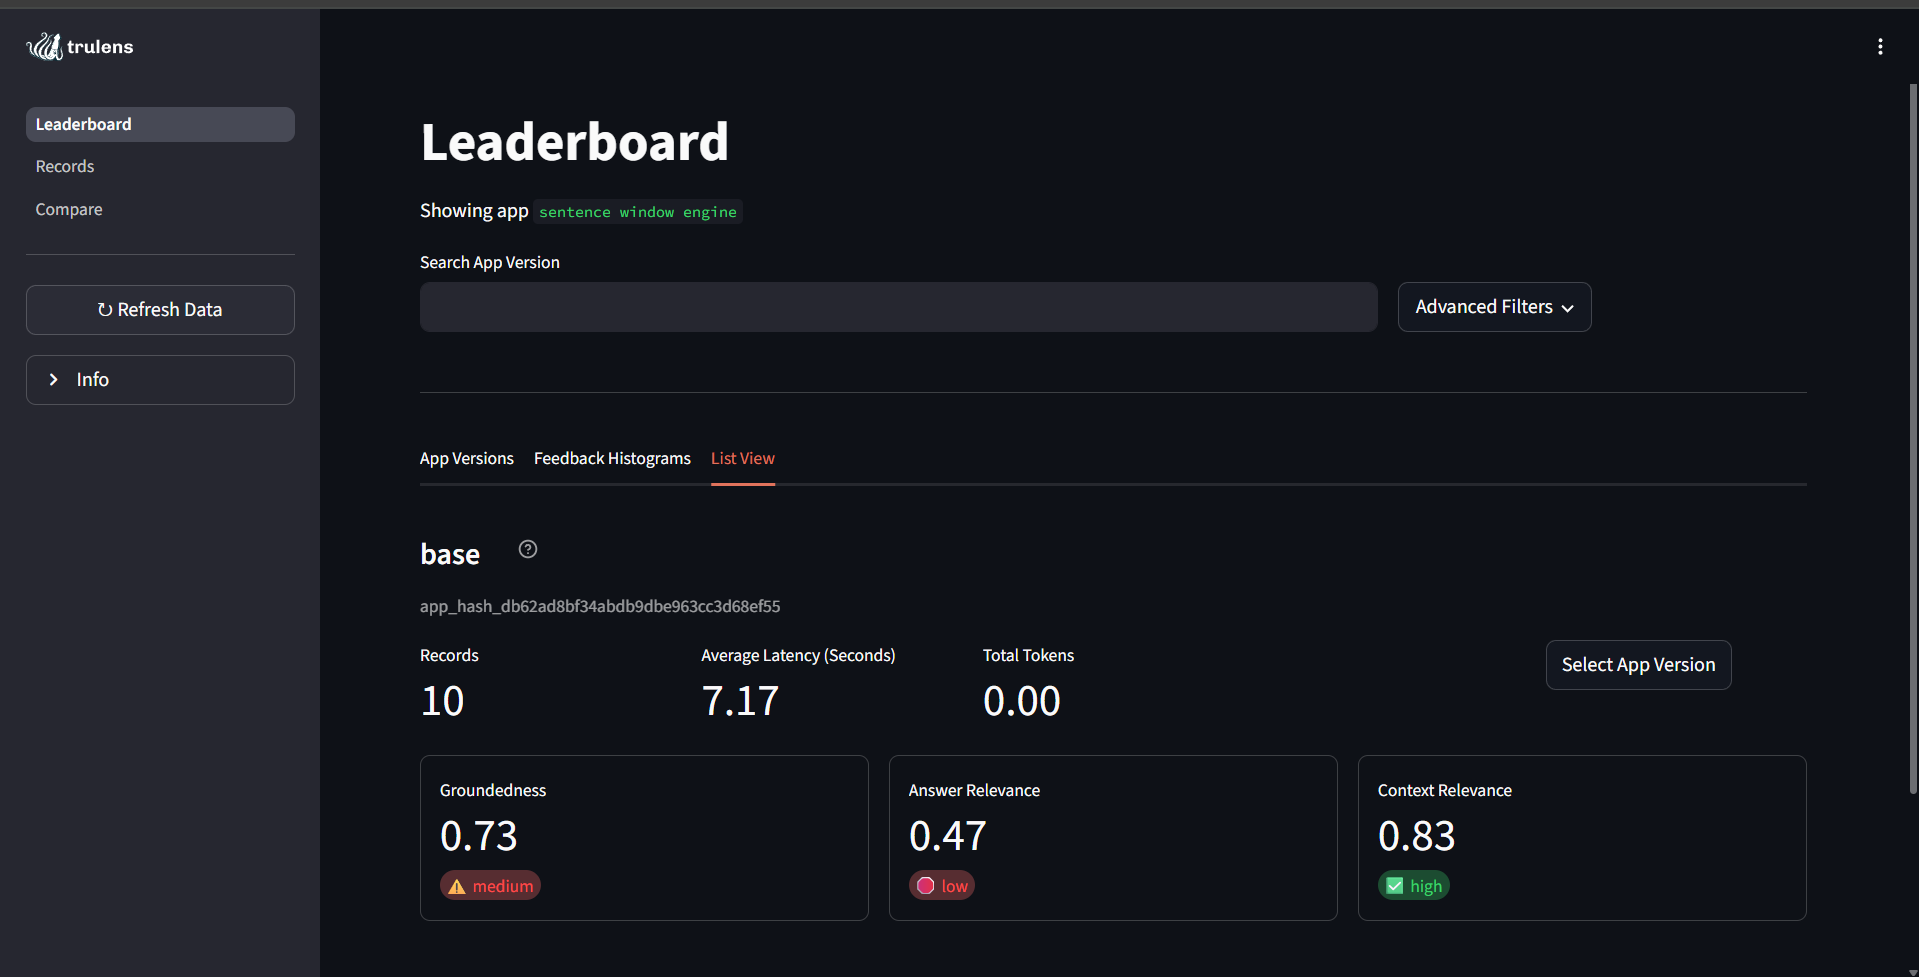

In [34]:
tru.stop_dashboard()